# K-means — demo WDBC (clustering)

Clustering **non supervisionato** sul dataset Breast Cancer Wisconsin con il `KMeans` scritto **da zero** (solo numpy). Le etichette vengono messe da parte durante il clustering e usate **solo** alla fine, per valutare quanto i cluster somiglino alla diagnosi reale. 

## 1. Setup e caricamento dati

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.kmeans import KMeans
from src.preprocessing import StandardScaler
from src.metrics import purity, silhouette, confusion_matrix

df = pd.read_csv('../data/raw/wdbc.csv')
feat = [c for c in df.columns if c not in ('target', 'diagnosis')]
X = df[feat].values            # 30 feature
y = df['target'].values        # 0=maligno, 1=benigno -- SOLO per valutazione finale
print('shape:', X.shape)
df['diagnosis'].value_counts()

shape: (569, 30)


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

## 2. Standardizzazione

K-means assegna i punti in base alla **distanza euclidea**: senza standardizzare, le feature con valori grandi (es. `area` ~1000) dominerebbero quelle piccole. Quindi si standardizza — al contrario del Naïve Bayes, che è invariante alla scala.

In [2]:
Xs = StandardScaler().fit_transform(X)
print('media ~0, std ~1 dopo scaling:', np.round(Xs.mean(), 3), np.round(Xs.std(), 3))

media ~0, std ~1 dopo scaling: -0.0 1.0


## 3. Scelta di K: metodo del gomito

Si esegue k-means per K crescenti e si osserva la **distorsione** $J$. Il "gomito" è il punto oltre il quale aggiungere cluster non riduce più di molto $J$.

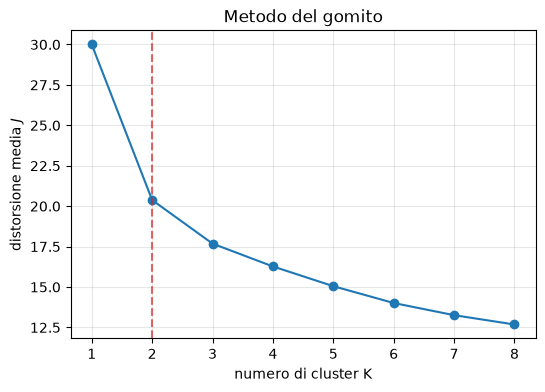

Il gomito e' intorno a K=2, coerente con le due diagnosi (maligno/benigno).


In [3]:
Ks = range(1, 9)
inertie = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs).inertia_ for k in Ks]
plt.figure(figsize=(6, 4))
plt.plot(list(Ks), inertie, '-o')
plt.axvline(2, ls='--', color='tab:red', alpha=0.7)
plt.xlabel('numero di cluster K'); plt.ylabel(r'distorsione media $J$')
plt.title('Metodo del gomito'); plt.grid(True, alpha=0.3); plt.show()
print('Il gomito e\' intorno a K=2, coerente con le due diagnosi (maligno/benigno).')

## 4. K-means con K = 2

Inizializzazione **k-means++** e 10 restart (si tiene la distorsione minima).

In [4]:
km = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42).fit(Xs)
print('distorsione J (media): %.4f' % km.inertia_)
print('iterazioni del miglior restart:', km.n_iter_)
print('dimensione dei cluster:', np.bincount(km.labels_))

distorsione J (media): 20.3787
iterazioni del miglior restart: 7
dimensione dei cluster: [380 189]


## 5. Confronto cluster vs diagnosi (validazione esterna)

Ora si riusano le etichette: quanto i cluster trovati **senza supervisione** somigliano alla diagnosi reale?

In [5]:
C = confusion_matrix(km.labels_, y, labels=[0, 1])   # righe = cluster, colonne = classe
print('righe = cluster, colonne = classe (0=maligno, 1=benigno):')
print(C)
print('\npurity = %.4f' % purity(y, km.labels_))
print('-> ogni cluster e\' assegnato alla classe di maggioranza; la purity e\' la frazione corretta.')

righe = cluster, colonne = classe (0=maligno, 1=benigno):
[[ 37 343]
 [175  14]]

purity = 0.9104
-> ogni cluster e' assegnato alla classe di maggioranza; la purity e' la frazione corretta.


## 6. Silhouette (validazione interna)

Senza usare le etichette: quanto sono **compatti e separati** i cluster? Vicino a 1 = ottimo, vicino a 0 = cluster sovrapposti.

In [6]:
print('silhouette media: %.4f' % silhouette(Xs, km.labels_))

silhouette media: 0.3450


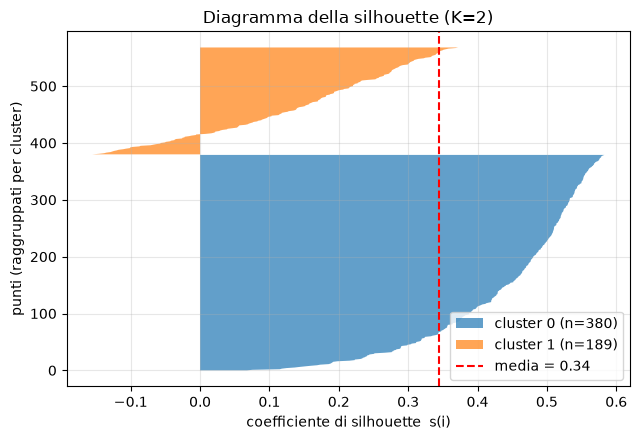

In [7]:
sil = silhouette(Xs, km.labels_, return_samples=True)   # array per-punto, calcolato nei .py
sil_avg = sil.mean()

plt.figure(figsize=(6.5, 4.5))
y_lower = 0
for k in np.unique(km.labels_):
    vals = np.sort(sil[km.labels_ == k])            # ordinati dentro al cluster
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7,
                      label=f'cluster {k} (n={len(vals)})')
    y_lower = y_upper
plt.axvline(sil_avg, color='red', ls='--', label=f'media = {sil_avg:.2f}')
plt.xlabel('coefficiente di silhouette  s(i)')
plt.ylabel('punti (raggruppati per cluster)')
plt.title('Diagramma della silhouette (K=2)')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 7. Confronto con sklearn e WEKA

Riferimento esterno per validare l'implementazione (la numerazione dei cluster è arbitraria, quindi si confrontano **distorsione** e distribuzione dei cluster, non le etichette).

> WEKA (v3.8.7, `SimpleKMeans`, K=2, n\_init=1, dati standardizzati, 569 istanze) trova gli stessi 2 cluster dell'implementazione: 380 e 189 istanze. La distorsione WEKA (SSE=215.84) usa una formula diversa e non è confrontabile numericamente con sklearn/implementazione.

In [8]:
from sklearn.cluster import KMeans as SKKMeans
from sklearn.metrics import silhouette_score
sk = SKKMeans(n_clusters=2, n_init=10, random_state=0).fit(Xs)
print('distorsione (somma)  implementazione: %.1f   sklearn: %.1f' % (km.inertia_*len(Xs), sk.inertia_))
print('silhouette           implementazione: %.4f   sklearn: %.4f' % (silhouette(Xs, km.labels_), silhouette_score(Xs, sk.labels_)))
print('purity               implementazione: %.4f   sklearn: %.4f' % (purity(y, km.labels_), purity(y, sk.labels_)))

distorsione (somma)  implementazione: 11595.5   sklearn: 11595.5
silhouette           implementazione: 0.3450   sklearn: 0.3434
purity               implementazione: 0.9104   sklearn: 0.9051


In [10]:
# WEKA SimpleKMeans (v3.8.7, K=2, n_init=1, dati standardizzati, 569 istanze)
# Cluster 0: 380 istanze (z < 0 → cellule piccole → benigno)
# Cluster 1: 189 istanze (z > 0 → cellule grandi → maligno)

impl_sizes = sorted((int((km.labels_ == k).sum()) for k in range(2)), reverse=True)
sk_sizes   = sorted((int((sk.labels_ == k).sum()) for k in range(2)), reverse=True)

print('--- Distribuzione cluster (569 istanze, dati standardizzati) ---')
print('implementazione: ', impl_sizes)
print('sklearn:         ', sk_sizes)
print('WEKA:            ', [380, 189])

--- Distribuzione cluster (569 istanze, dati standardizzati) ---
implementazione:  [380, 189]
sklearn:          [375, 194]
WEKA:             [380, 189]
